In [1]:
from PIL import Image
import numpy as np
from matplotlib import pyplot as plt

In [2]:
img_gray = Image.open("C:/Users/PC-LAB1/img_processing_lab/images/Original_lena512.jpg")
image_gray = np.array(img_gray)

img_rgb = Image.open("C:/Users/PC-LAB1/img_processing_lab/images/lena5.jpg")
image_rgb = np.array(img_rgb)

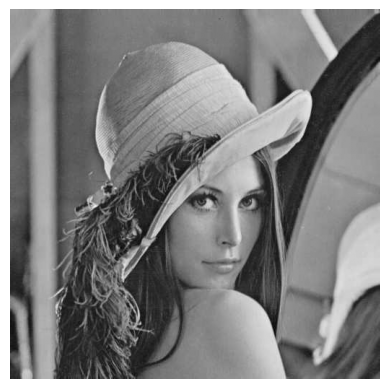

In [3]:
plt.imshow(image_gray, cmap="gray")
plt.axis("off")
plt.show()

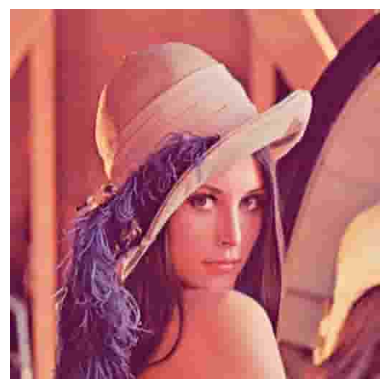

In [4]:
plt.imshow(image_rgb, cmap="gray")
plt.axis("off")
plt.show()

In [5]:
print("Shape:", image_gray.shape)
print("Data type:", image_gray.dtype)
print("Minimum:", image_gray.min())
print("Maximum:", image_gray.max())
print("Mean:", image_gray.mean())


Shape: (512, 512)
Data type: uint8
Minimum: 10
Maximum: 255
Mean: 124.06368255615234


In [6]:
print("Shape:", image_rgb.shape)
print("Data type:", image_rgb.dtype)
print("Minimum:", image_rgb.min())
print("Maximum:", image_rgb.max())
print("Mean:", image_rgb.mean())

Shape: (512, 512, 3)
Data type: uint8
Minimum: 0
Maximum: 255
Mean: 128.09458033243814


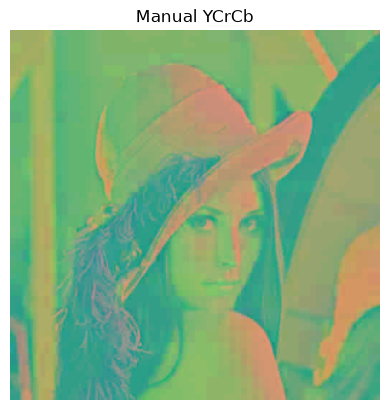

Shape: (512, 512, 3)
Data type: uint8
Minimum: 10
Maximum: 248
Mean: 135.87810134887695


In [7]:
# Extract and cast color channels to float
R = image_rgb[:, :, 0].astype(np.float32)
G = image_rgb[:, :, 1].astype(np.float32)
B = image_rgb[:, :, 2].astype(np.float32)

# Apply conversion equations
Y  =  0.29900 * R + 0.58700 * G + 0.11400 * B
Cr = (0.50000 * R - 0.41869 * G - 0.08131 * B) + 128
Cb = (-0.16874 * R - 0.33126 * G + 0.50000 * B) + 128

# Stack channels and clip values to valid [0, 255] range
image_ycrcb = np.clip(np.stack([Y, Cr, Cb], axis=-1), 0, 255).astype(np.uint8)

plt.imshow(image_ycrcb)
plt.title("Manual YCrCb")
plt.axis("off")
plt.show()

print("Shape:", image_ycrcb.shape)
print("Data type:", image_ycrcb.dtype)
print("Minimum:", image_ycrcb.min())
print("Maximum:", image_ycrcb.max())
print("Mean:", image_ycrcb.mean())

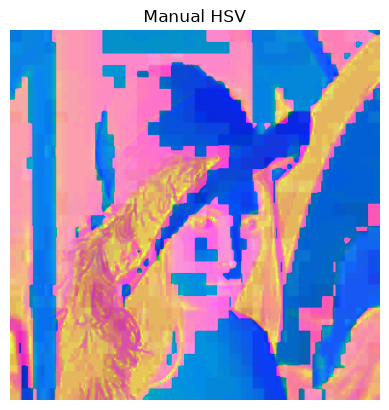

Shape: (512, 512, 3)
Data type: float32
Minimum: 0.0
Maximum: 1.0
Mean: 0.5898079


In [ ]:
# Normalize RGB values to [0, 1]
rgb_norm = image_rgb.astype(np.float32) / 255.0
r, g, b = rgb_norm[..., 0], rgb_norm[..., 1], rgb_norm[..., 2]

cmax = np.max(rgb_norm, axis=-1)
cmin = np.min(rgb_norm, axis=-1)
diff = cmax - cmin

# Initialize arrays
h = np.zeros_like(cmax)
s = np.zeros_like(cmax)
v = cmax

# Calculate Saturation
s[cmax != 0] = diff[cmax != 0] / cmax[cmax != 0]

# Calculate Hue for each case
idx_r = (cmax == r) & (diff != 0)
h[idx_r] = (60 * ((g[idx_r] - b[idx_r]) / diff[idx_r]) + 360) % 360

idx_g = (cmax == g) & (diff != 0)
h[idx_g] = (60 * ((b[idx_g] - r[idx_g]) / diff[idx_g]) + 120) % 360

idx_b = (cmax == b) & (diff != 0)
h[idx_b] = (60 * ((r[idx_b] - g[idx_b]) / diff[idx_b]) + 240) % 360

# Prepare normalized HSV image for Matplotlib ([0, 1] range)
image_hsv_disp = np.stack([h / 360.0, s, v], axis=-1)

plt.imshow(image_hsv_disp)
plt.title("Manual HSV")
plt.axis("off")
plt.show()

print("Shape:", image_hsv_disp.shape)
print("Data type:", image_hsv_disp.dtype)
print("Minimum:", image_hsv_disp.min())
print("Maximum:", image_hsv_disp.max())
print("Mean:", image_hsv_disp.mean())

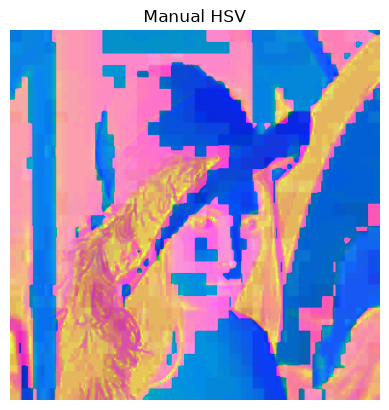

Shape: (512, 512, 3)
Data type: float32
Minimum: 0.0
Maximum: 1.0
Mean: 0.5898079


In [8]:
# Normalize RGB values to [0, 1]
rgb_norm = image_rgb.astype(np.float32) / 255.0
r, g, b = rgb_norm[..., 0], rgb_norm[..., 1], rgb_norm[..., 2]

cmax = np.max(rgb_norm, axis=-1)
cmin = np.min(rgb_norm, axis=-1)
diff = cmax - cmin

# Initialize arrays
h = np.zeros_like(cmax)
s = np.zeros_like(cmax)
v = cmax

# Calculate Saturation
s[cmax != 0] = diff[cmax != 0] / cmax[cmax != 0]

# Calculate Hue for each case
idx_r = (cmax == r) & (diff != 0)
h[idx_r] = (60 * ((g[idx_r] - b[idx_r]) / diff[idx_r]) + 360) % 360

idx_g = (cmax == g) & (diff != 0)
h[idx_g] = (60 * ((b[idx_g] - r[idx_g]) / diff[idx_g]) + 120) % 360

idx_b = (cmax == b) & (diff != 0)
h[idx_b] = (60 * ((r[idx_b] - g[idx_b]) / diff[idx_b]) + 240) % 360

# Prepare normalized HSV image for Matplotlib ([0, 1] range)
image_hsv_disp = np.stack([h / 360.0, s, v], axis=-1)

plt.imshow(image_hsv_disp)
plt.title("Manual HSV")
plt.axis("off")
plt.show()

print("Shape:", image_hsv_disp.shape)
print("Data type:", image_hsv_disp.dtype)
print("Minimum:", image_hsv_disp.min())
print("Maximum:", image_hsv_disp.max())
print("Mean:", image_hsv_disp.mean())